<a href="https://colab.research.google.com/github/habibiputrar/DeepLearning_B_2411531001_Habibi-Putra-Rizqullah/blob/main/Praktikum3/Praktikum3_DeepLearning.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# PRAKTIKUM DAN TUGAS PRAKTIKUM 3 DEEP LEARNING

## Recurrent Neural Network untuk Data Sekuensial

**Nama:** Habibi Putra Rizqullah  
**NIM:** 2411531001  
**Kelas:** Deep Learning B



# BAGIAN I

# PRAKTIKUM

## Prediksi Deret Sinusoidal Menggunakan RNN

Bagian ini membahas pembuatan model Recurrent Neural Network untuk memprediksi nilai berikutnya pada deret sinusoidal.


### 1. Mengimpor Library dan Menentukan Perangkat

Library `NumPy` digunakan untuk membuat data, `Matplotlib` untuk menampilkan grafik, dan `PyTorch` untuk membangun model RNN. Seed ditetapkan agar hasil percobaan lebih konsisten.


In [1]:
import random
import time

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
import torch.nn as nn

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Perangkat yang digunakan: {device}")


Perangkat yang digunakan: cpu


### 2. Membuat Data Sinusoidal

Data terdiri atas 1.000 titik dari fungsi sinus. Grafik awal ditampilkan untuk melihat bentuk pola yang akan dipelajari oleh model.


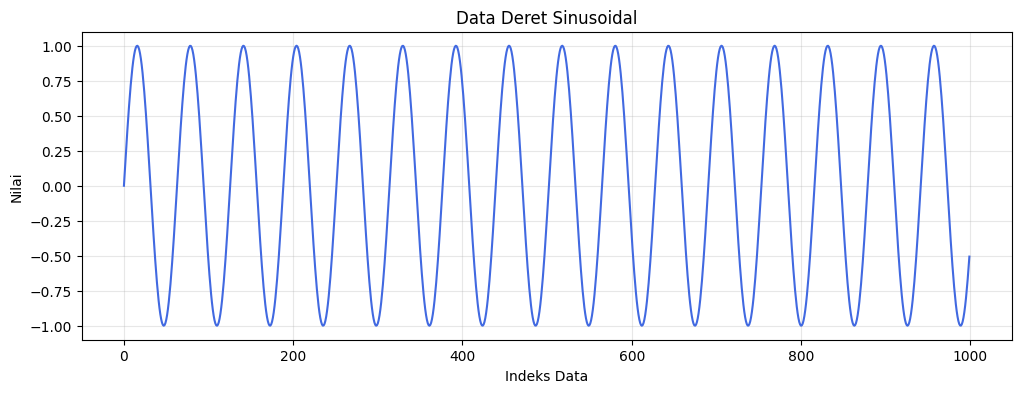

In [2]:
data = np.sin(np.linspace(0, 100, 1000)).astype(np.float32)

plt.figure(figsize=(12, 4))
plt.plot(data, color="royalblue")
plt.title("Data Deret Sinusoidal")
plt.xlabel("Indeks Data")
plt.ylabel("Nilai")
plt.grid(alpha=0.3)
plt.show()


### 3. Membentuk Data Sekuensial

Setiap sampel berisi sepuluh nilai berurutan sebagai input. Nilai setelah urutan tersebut digunakan sebagai target prediksi.


In [3]:
seq_length = 10

def create_sequences(series, sequence_length):
    xs, ys = [], []
    for i in range(len(series) - sequence_length):
        xs.append(series[i:i + sequence_length])
        ys.append(series[i + sequence_length])
    return np.array(xs), np.array(ys)

X_np, y_np = create_sequences(data, seq_length)

X = torch.tensor(X_np, dtype=torch.float32).unsqueeze(-1).to(device)
y = torch.tensor(y_np, dtype=torch.float32).unsqueeze(-1).to(device)

print(f"Bentuk X: {X.shape}")
print(f"Bentuk y: {y.shape}")
print(f"Contoh urutan pertama: {X_np[0]}")
print(f"Target pertama: {y_np[0]:.4f}")


Bentuk X: torch.Size([990, 10, 1])
Bentuk y: torch.Size([990, 1])
Contoh urutan pertama: [0.         0.09993301 0.19886553 0.2958071  0.3897871  0.47986472
 0.56513804 0.64475346 0.7179138  0.7838866 ]
Target pertama: 0.8420


### 4. Mendefinisikan Model RNN

Lapisan RNN menerima satu fitur pada setiap langkah waktu. Hidden state terakhir diteruskan ke lapisan linear untuk menghasilkan satu nilai prediksi.


In [4]:
class RNNModel(nn.Module):
    def __init__(self, input_size=1, hidden_size=32, output_size=1):
        super().__init__()
        self.rnn = nn.RNN(
            input_size=input_size,
            hidden_size=hidden_size,
            batch_first=True,
        )
        self.fc = nn.Linear(hidden_size, output_size)

    def forward(self, x):
        output, _ = self.rnn(x)
        last_output = output[:, -1, :]
        return self.fc(last_output)


model_check = RNNModel(hidden_size=32).to(device)
dummy_input = torch.randn(4, seq_length, 1, device=device)
print(model_check)
print(f"Bentuk output: {model_check(dummy_input).shape}")


RNNModel(
  (rnn): RNN(1, 32, batch_first=True)
  (fc): Linear(in_features=32, out_features=1, bias=True)
)
Bentuk output: torch.Size([4, 1])


### 5. Membuat Fungsi Training

Fungsi berikut digunakan agar model dengan jumlah neuron tersembunyi yang berbeda dapat dilatih menggunakan proses yang sama. Loss dihitung menggunakan MSE, sedangkan bobot diperbarui dengan optimizer Adam.


In [5]:
def train_rnn(hidden_size, X_data, y_data, epochs=50, learning_rate=0.01, verbose=False):
    torch.manual_seed(SEED)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(SEED)

    model = RNNModel(hidden_size=hidden_size).to(device)
    criterion = nn.MSELoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate)
    losses = []

    start_time = time.perf_counter()

    for epoch in range(epochs):
        model.train()
        optimizer.zero_grad()

        outputs = model(X_data)
        loss = criterion(outputs, y_data)
        loss.backward()
        optimizer.step()

        losses.append(loss.item())

        if verbose and (epoch + 1) % 10 == 0:
            print(
                f"Epoch [{epoch + 1}/{epochs}] | "
                f"Loss: {loss.item():.6f}"
            )

    training_time = time.perf_counter() - start_time

    model.eval()
    with torch.no_grad():
        predictions = model(X_data)
        final_loss = criterion(predictions, y_data).item()
        mae = torch.mean(torch.abs(predictions - y_data)).item()

    return {
        "model": model,
        "losses": losses,
        "predictions": predictions.cpu().numpy().flatten(),
        "final_loss": final_loss,
        "mae": mae,
        "training_time": training_time,
    }


### 6. Melatih Model Dasar

Model dasar menggunakan `hidden_size=32`, learning rate 0,01, dan 50 epoch sesuai contoh pada modul.


In [6]:
baseline_result = train_rnn(
    hidden_size=32,
    X_data=X,
    y_data=y,
    epochs=50,
    learning_rate=0.01,
    verbose=True,
)

print(f"Loss akhir: {baseline_result['final_loss']:.6f}")
print(f"MAE: {baseline_result['mae']:.6f}")
print(f"Waktu training: {baseline_result['training_time']:.2f} detik")


Epoch [10/50] | Loss: 0.032236
Epoch [20/50] | Loss: 0.014353
Epoch [30/50] | Loss: 0.004758
Epoch [40/50] | Loss: 0.001186
Epoch [50/50] | Loss: 0.000439
Loss akhir: 0.000645
MAE: 0.022233
Waktu training: 0.34 detik


### 7. Menampilkan Grafik Loss

Grafik loss digunakan untuk melihat perubahan kesalahan model pada setiap epoch. Training berjalan baik apabila loss cenderung menurun dan mulai stabil.


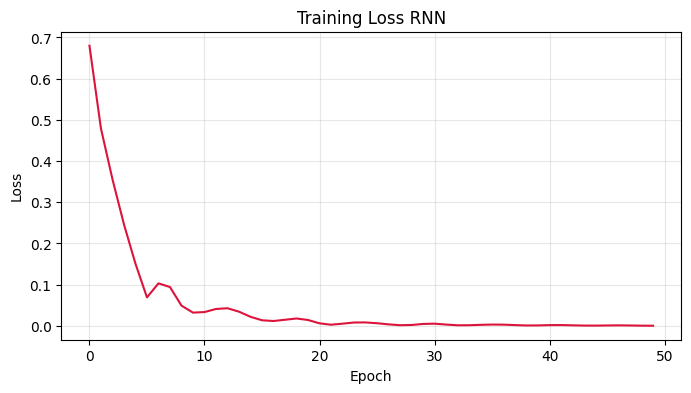

In [7]:
plt.figure(figsize=(8, 4))
plt.plot(baseline_result["losses"], color="crimson")
plt.title("Training Loss RNN")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.grid(alpha=0.3)
plt.show()


### 8. Membandingkan Data Asli dan Prediksi

Prediksi ditempatkan mulai dari indeks ke-10 karena sepuluh nilai pertama digunakan sebagai input awal model.


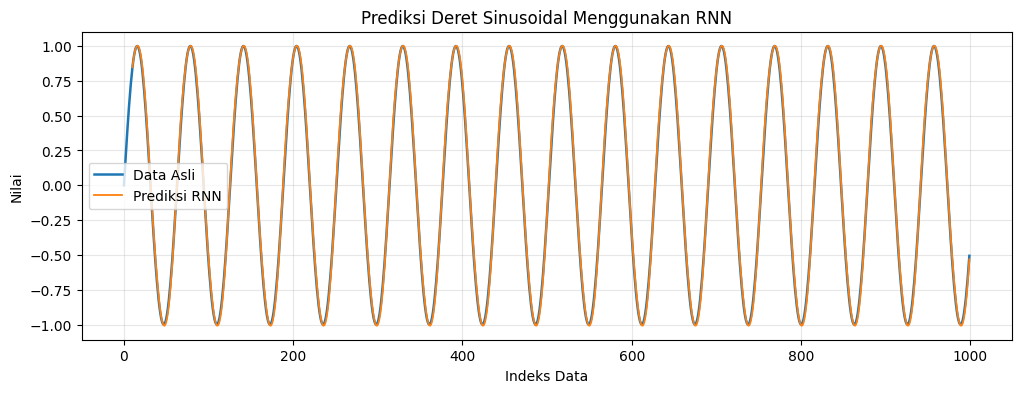

In [8]:
prediction_index = np.arange(seq_length, seq_length + len(baseline_result["predictions"]))

plt.figure(figsize=(12, 4))
plt.plot(data, label="Data Asli", linewidth=1.8)
plt.plot(
    prediction_index,
    baseline_result["predictions"],
    label="Prediksi RNN",
    linewidth=1.3,
)
plt.title("Prediksi Deret Sinusoidal Menggunakan RNN")
plt.xlabel("Indeks Data")
plt.ylabel("Nilai")
plt.legend()
plt.grid(alpha=0.3)
plt.show()


### 9. Percobaan Hidden Size

Hidden size diubah menjadi 16, 64, dan 128. Hasil model dasar berukuran 32 tetap disertakan agar seluruh konfigurasi dapat dibandingkan pada tabel yang sama.


In [9]:
experiment_results = {32: baseline_result}

for hidden_size in [16, 64, 128]:
    print(f"Melatih RNN dengan hidden size {hidden_size}...")
    experiment_results[hidden_size] = train_rnn(
        hidden_size=hidden_size,
        X_data=X,
        y_data=y,
        epochs=50,
        learning_rate=0.01,
    )

comparison_rows = []
for hidden_size in sorted(experiment_results):
    result = experiment_results[hidden_size]
    comparison_rows.append({
        "Hidden Size": hidden_size,
        "Loss Akhir": result["final_loss"],
        "MAE": result["mae"],
        "Waktu Training (s)": result["training_time"],
    })

comparison_table = pd.DataFrame(comparison_rows)
comparison_table[["Loss Akhir", "MAE", "Waktu Training (s)"]] = (
    comparison_table[["Loss Akhir", "MAE", "Waktu Training (s)"]].round(6)
)
comparison_table


Melatih RNN dengan hidden size 16...
Melatih RNN dengan hidden size 64...
Melatih RNN dengan hidden size 128...


,Hidden Size,Loss Akhir,MAE,Waktu Training (s)
0,16,0.001317,0.030857,0.170915
1,32,0.000645,0.022233,0.342106
2,64,0.000309,0.015652,0.631057
3,128,0.017990,0.116396,1.679071


### 10. Grafik Perbandingan Eksperimen

Grafik kiri membandingkan penurunan loss. Empat grafik berikutnya memperlihatkan bentuk prediksi dari setiap hidden size.


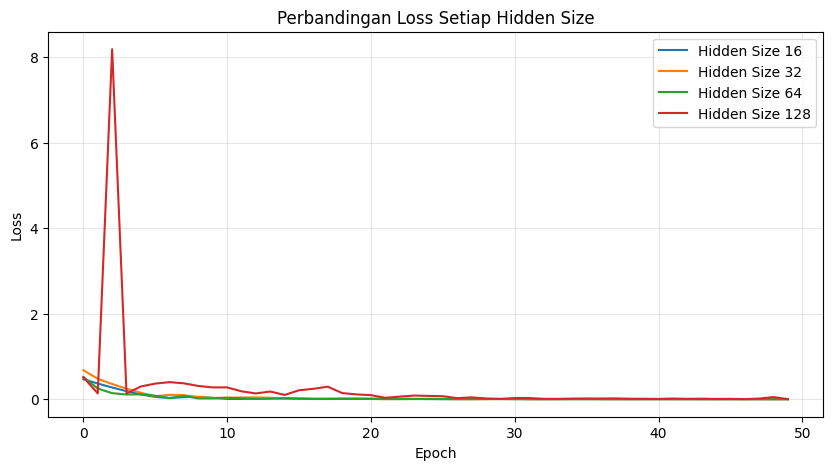

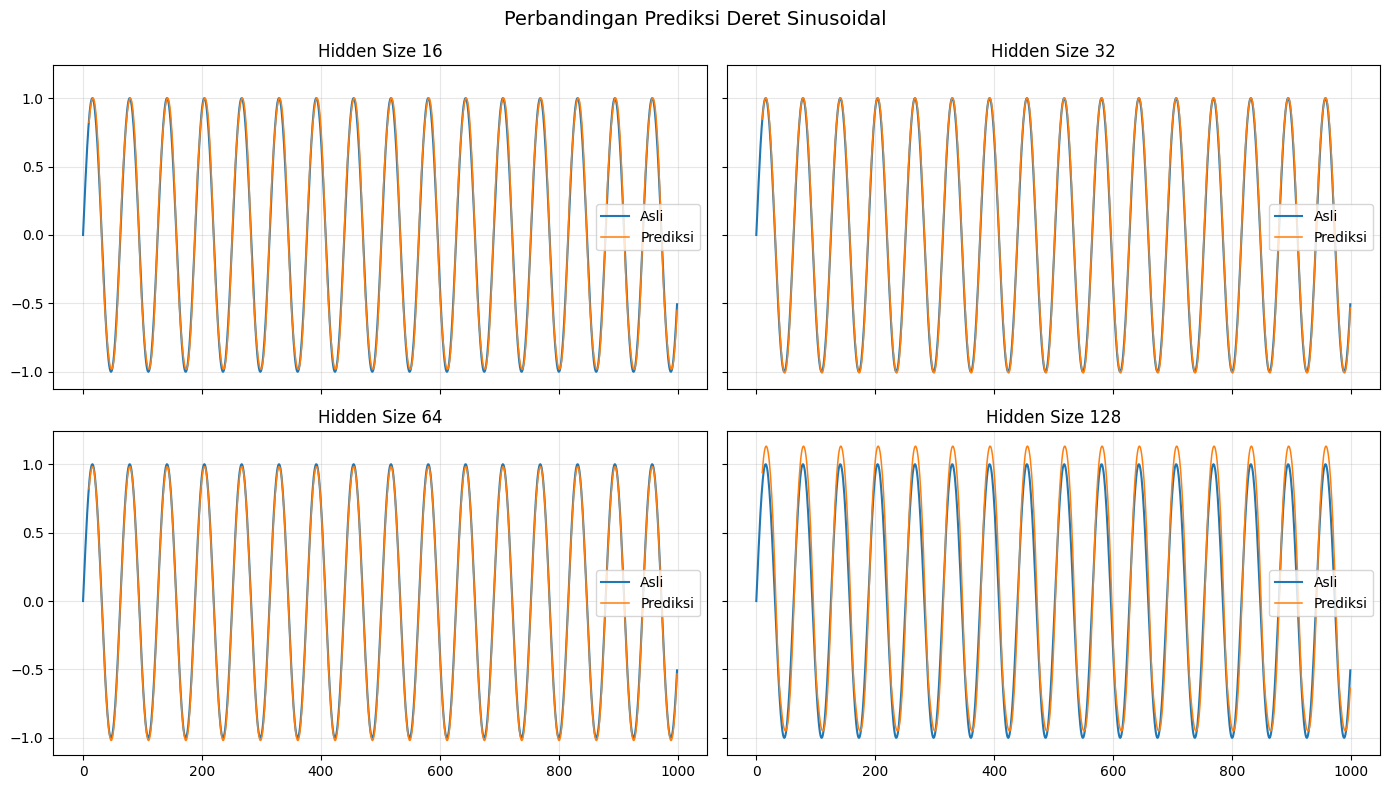

In [10]:
plt.figure(figsize=(10, 5))
for hidden_size in sorted(experiment_results):
    plt.plot(
        experiment_results[hidden_size]["losses"],
        label=f"Hidden Size {hidden_size}",
    )
plt.title("Perbandingan Loss Setiap Hidden Size")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

fig, axes = plt.subplots(2, 2, figsize=(14, 8), sharex=True, sharey=True)
for ax, hidden_size in zip(axes.flat, sorted(experiment_results)):
    ax.plot(data, label="Asli", linewidth=1.5)
    ax.plot(
        prediction_index,
        experiment_results[hidden_size]["predictions"],
        label="Prediksi",
        linewidth=1.1,
    )
    ax.set_title(f"Hidden Size {hidden_size}")
    ax.grid(alpha=0.3)
    ax.legend()

fig.suptitle("Perbandingan Prediksi Deret Sinusoidal", fontsize=14)
plt.tight_layout()
plt.show()


### 11. Analisis Hasil

Loss akhir yang lebih kecil menunjukkan prediksi lebih dekat terhadap target. Penambahan hidden size memperbesar kapasitas model untuk menyimpan informasi, tetapi jumlah perhitungan dan waktu training juga bertambah. Hidden size terbesar tidak selalu menjadi pilihan terbaik karena hasilnya tetap dipengaruhi oleh inisialisasi bobot, learning rate, dan jumlah epoch.


In [11]:
best_row = comparison_table.loc[comparison_table["Loss Akhir"].idxmin()]
fastest_row = comparison_table.loc[comparison_table["Waktu Training (s)"].idxmin()]

print("Ringkasan hasil:")
print(
    f"- Loss terendah diperoleh hidden size {int(best_row['Hidden Size'])} "
    f"dengan loss {best_row['Loss Akhir']:.6f}."
)
print(
    f"- Waktu tercepat diperoleh hidden size {int(fastest_row['Hidden Size'])} "
    f"selama {fastest_row['Waktu Training (s)']:.6f} detik."
)
print("- Pemilihan model perlu mempertimbangkan ketelitian dan waktu training.")


Ringkasan hasil:
- Loss terendah diperoleh hidden size 64 dengan loss 0.000309.
- Waktu tercepat diperoleh hidden size 16 selama 0.170915 detik.
- Pemilihan model perlu mempertimbangkan ketelitian dan waktu training.


---

# BAGIAN II

# TUGAS INDIVIDU

## Prediksi Deret Cosine dan Eksperimen Hidden Size RNN

Bagian ini berisi penerapan RNN pada pola cosine serta perbandingan beberapa nilai hidden size untuk melihat pengaruhnya terhadap hasil prediksi dan waktu pelatihan.


### 1. Mengimpor Library dan Menentukan Perangkat

Library dan seed disiapkan terlebih dahulu agar seluruh percobaan menggunakan kondisi awal yang sama.


In [12]:
import random
import time

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
import torch.nn as nn

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Perangkat yang digunakan: {device}")


Perangkat yang digunakan: cpu


### 2. Membuat Data Cosine

Data tugas dibuat dari fungsi cosine sebanyak 1.000 titik. Bentuk datanya tetap berurutan sehingga sesuai digunakan pada RNN.


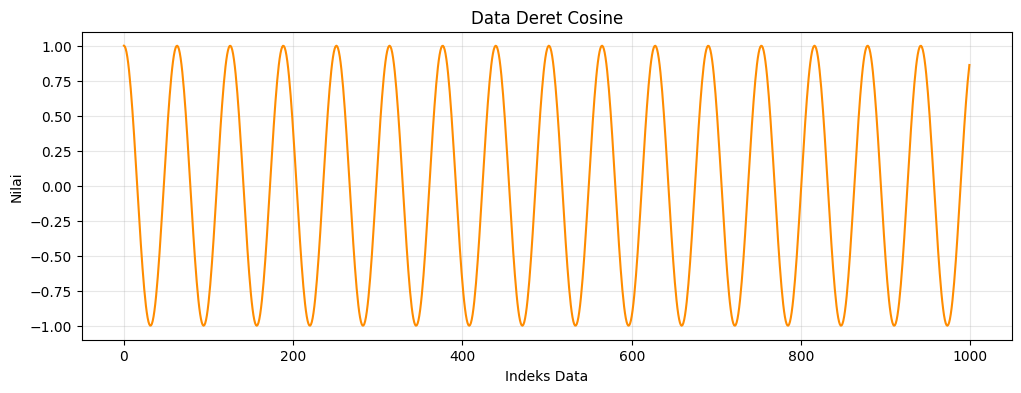

In [13]:
data = np.cos(np.linspace(0, 100, 1000)).astype(np.float32)

plt.figure(figsize=(12, 4))
plt.plot(data, color="darkorange")
plt.title("Data Deret Cosine")
plt.xlabel("Indeks Data")
plt.ylabel("Nilai")
plt.grid(alpha=0.3)
plt.show()


### 3. Membentuk Urutan Input dan Target

Setiap input berisi sepuluh nilai cosine. Targetnya adalah nilai yang muncul tepat setelah urutan input tersebut.


In [14]:
seq_length = 10

def create_sequences(series, sequence_length):
    xs, ys = [], []
    for i in range(len(series) - sequence_length):
        xs.append(series[i:i + sequence_length])
        ys.append(series[i + sequence_length])
    return np.array(xs), np.array(ys)

X_np, y_np = create_sequences(data, seq_length)

X = torch.tensor(X_np, dtype=torch.float32).unsqueeze(-1).to(device)
y = torch.tensor(y_np, dtype=torch.float32).unsqueeze(-1).to(device)

print(f"Bentuk X: {X.shape}")
print(f"Bentuk y: {y.shape}")


Bentuk X: torch.Size([990, 10, 1])
Bentuk y: torch.Size([990, 1])


### 4. Mendefinisikan Arsitektur RNN

Arsitektur terdiri atas satu lapisan RNN dan satu lapisan linear. Jumlah neuron pada hidden state akan diubah pada setiap eksperimen.


In [15]:
class RNNModel(nn.Module):
    def __init__(self, input_size=1, hidden_size=32, output_size=1):
        super().__init__()
        self.rnn = nn.RNN(
            input_size=input_size,
            hidden_size=hidden_size,
            batch_first=True,
        )
        self.fc = nn.Linear(hidden_size, output_size)

    def forward(self, x):
        output, _ = self.rnn(x)
        return self.fc(output[:, -1, :])


### 5. Membuat Fungsi Eksperimen

Fungsi ini melatih model selama 50 epoch, menyimpan loss, menghitung MAE, mencatat waktu training, dan menghasilkan prediksi.


In [16]:
def run_experiment(hidden_size, epochs=50, learning_rate=0.01):
    torch.manual_seed(SEED)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(SEED)

    model = RNNModel(hidden_size=hidden_size).to(device)
    criterion = nn.MSELoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate)
    losses = []

    start_time = time.perf_counter()

    for epoch in range(epochs):
        model.train()
        optimizer.zero_grad()

        outputs = model(X)
        loss = criterion(outputs, y)
        loss.backward()
        optimizer.step()

        losses.append(loss.item())

    training_time = time.perf_counter() - start_time

    model.eval()
    with torch.no_grad():
        predictions = model(X)
        final_loss = criterion(predictions, y).item()
        mae = torch.mean(torch.abs(predictions - y)).item()

    return {
        "model": model,
        "losses": losses,
        "predictions": predictions.cpu().numpy().flatten(),
        "final_loss": final_loss,
        "mae": mae,
        "training_time": training_time,
    }


### 6. Menjalankan Percobaan Hidden Size

Percobaan dilakukan pada hidden size 16, 32, dan 64. Parameter lain dibuat sama agar perbandingan tetap adil.


In [17]:
hidden_sizes = [16, 32, 64]
results = {}

for hidden_size in hidden_sizes:
    print(f"Melatih model dengan hidden size {hidden_size}...")
    results[hidden_size] = run_experiment(hidden_size=hidden_size)

print("Seluruh percobaan selesai.")


Melatih model dengan hidden size 16...
Melatih model dengan hidden size 32...
Melatih model dengan hidden size 64...
Seluruh percobaan selesai.


### 7. Menyusun Tabel Hasil

Keterangan pola prediksi ditentukan dari peringkat loss. Model dengan loss terendah diberi keterangan paling halus, sedangkan catatan waktu ditentukan dari lama training setiap model.


In [18]:
rows = []
for hidden_size in hidden_sizes:
    result = results[hidden_size]
    rows.append({
        "Hidden Size": hidden_size,
        "Loss Akhir": result["final_loss"],
        "MAE": result["mae"],
        "Waktu Training (s)": result["training_time"],
    })

result_table = pd.DataFrame(rows)

loss_order = result_table["Loss Akhir"].rank(method="dense").astype(int)
time_order = result_table["Waktu Training (s)"].rank(method="dense").astype(int)

pola_labels = {
    1: "sangat halus",
    2: "halus",
    3: "agak kasar",
}
time_labels = {
    1: "training paling cepat",
    2: "waktu training sedang",
    3: "training paling lama",
}

result_table["Pola Prediksi"] = loss_order.map(pola_labels)
result_table["Catatan"] = time_order.map(time_labels)

result_table[["Loss Akhir", "MAE", "Waktu Training (s)"]] = (
    result_table[["Loss Akhir", "MAE", "Waktu Training (s)"]].round(6)
)

result_table = result_table[
    [
        "Hidden Size",
        "Loss Akhir",
        "Pola Prediksi",
        "Catatan",
        "MAE",
        "Waktu Training (s)",
    ]
]
result_table


,Hidden Size,Loss Akhir,Pola Prediksi,Catatan,MAE,Waktu Training (s)
0,16,0.001187,agak kasar,training paling cepat,0.029918,0.172684
1,32,0.000489,halus,waktu training sedang,0.019445,0.263912
2,64,0.000228,sangat halus,training paling lama,0.012119,0.591929


### 8. Menampilkan Grafik Loss

Grafik berikut digunakan untuk membandingkan kecepatan penurunan loss dari setiap hidden size.


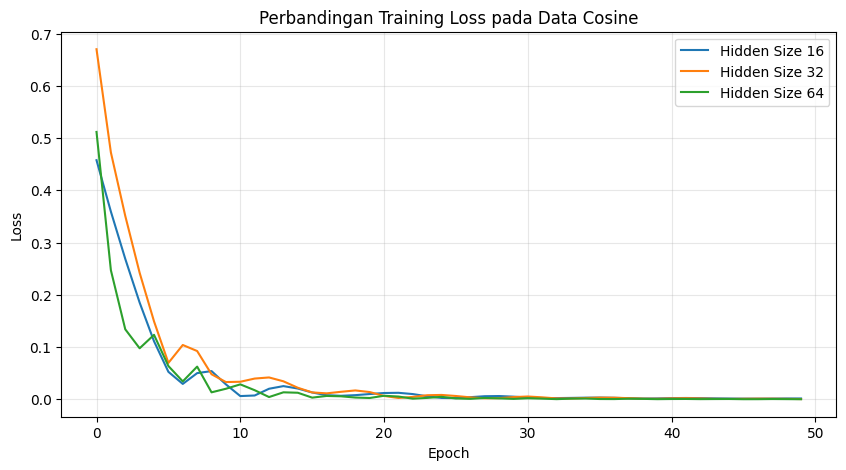

In [19]:
plt.figure(figsize=(10, 5))
for hidden_size in hidden_sizes:
    plt.plot(
        results[hidden_size]["losses"],
        label=f"Hidden Size {hidden_size}",
    )
plt.title("Perbandingan Training Loss pada Data Cosine")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid(alpha=0.3)
plt.show()


### 9. Membandingkan Hasil Prediksi

Setiap grafik menampilkan data cosine asli dan hasil prediksi model. Kurva yang semakin berhimpitan menunjukkan prediksi yang semakin baik.


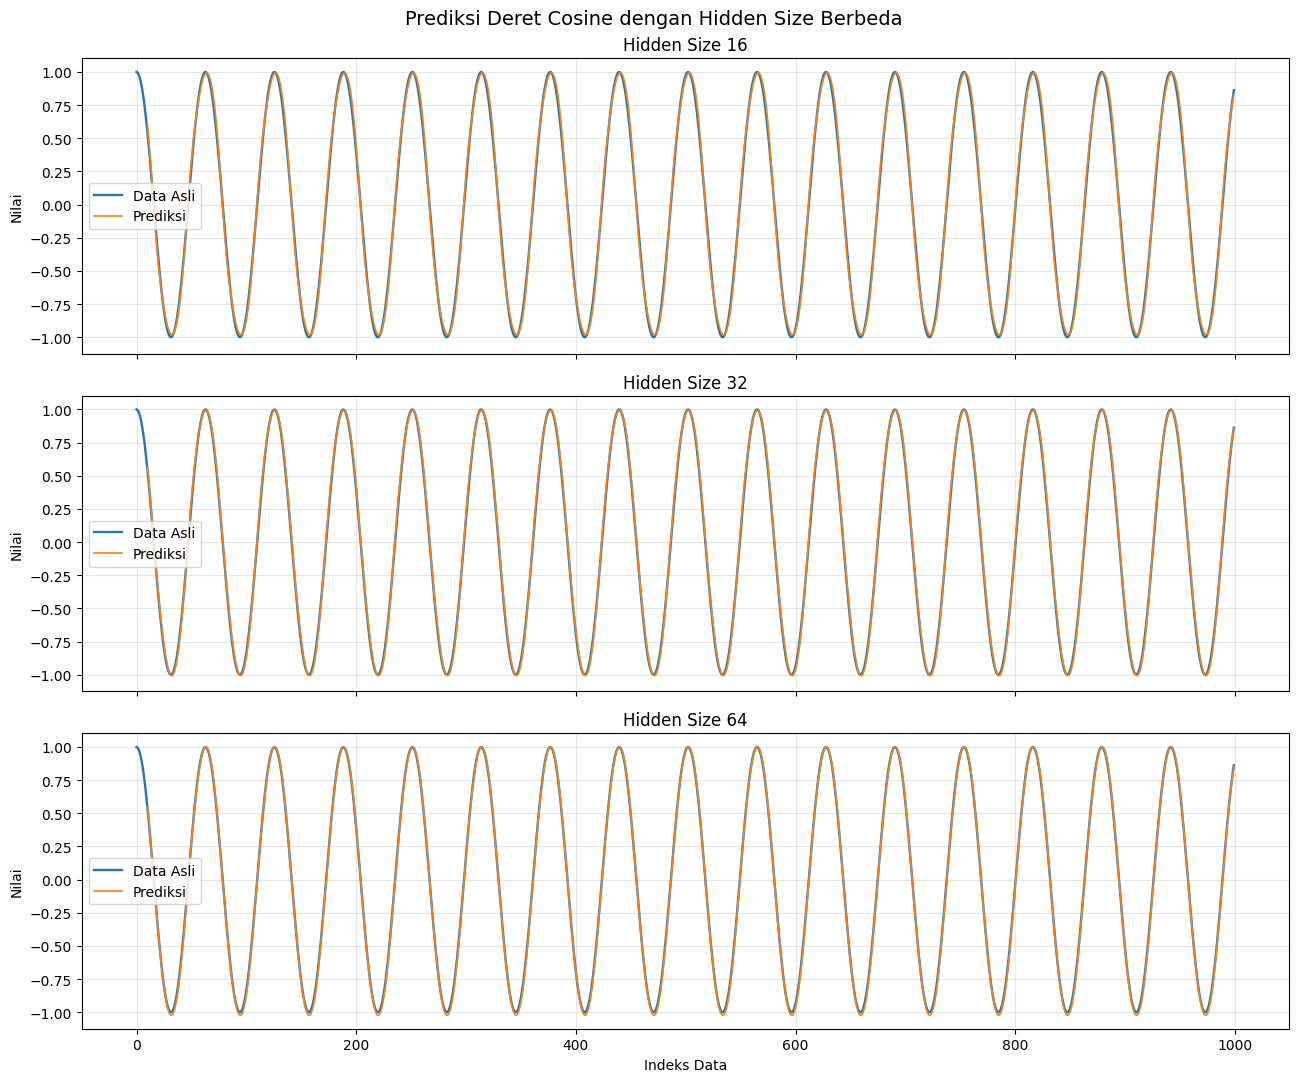

In [20]:
prediction_index = np.arange(seq_length, seq_length + len(y_np))

fig, axes = plt.subplots(3, 1, figsize=(13, 11), sharex=True, sharey=True)

for ax, hidden_size in zip(axes, hidden_sizes):
    ax.plot(data, label="Data Asli", linewidth=1.7)
    ax.plot(
        prediction_index,
        results[hidden_size]["predictions"],
        label="Prediksi",
        linewidth=1.2,
    )
    ax.set_title(f"Hidden Size {hidden_size}")
    ax.set_ylabel("Nilai")
    ax.grid(alpha=0.3)
    ax.legend()

axes[-1].set_xlabel("Indeks Data")
fig.suptitle("Prediksi Deret Cosine dengan Hidden Size Berbeda", fontsize=14)
plt.tight_layout()
plt.show()


### 10. Kesimpulan Percobaan

Jumlah neuron tersembunyi memengaruhi kapasitas model dalam menyimpan informasi urutan. Hidden size yang lebih besar dapat menghasilkan prediksi lebih halus, tetapi waktu training dan jumlah perhitungannya juga meningkat. Konfigurasi terbaik dipilih berdasarkan keseimbangan antara loss dan waktu training.


In [21]:
best_model = result_table.loc[result_table["Loss Akhir"].idxmin()]
fastest_model = result_table.loc[result_table["Waktu Training (s)"].idxmin()]

print("Kesimpulan hasil eksperimen:")
print(
    f"1. Hidden size {int(best_model['Hidden Size'])} menghasilkan loss "
    f"terendah sebesar {best_model['Loss Akhir']:.6f}."
)
print(
    f"2. Hidden size {int(fastest_model['Hidden Size'])} memiliki waktu "
    f"training paling cepat, yaitu {fastest_model['Waktu Training (s)']:.6f} detik."
)
print(
    "3. Hidden size yang lebih besar menambah kapasitas model, tetapi "
    "tidak selalu menjadi pilihan paling efisien."
)


Kesimpulan hasil eksperimen:
1. Hidden size 64 menghasilkan loss terendah sebesar 0.000228.
2. Hidden size 16 memiliki waktu training paling cepat, yaitu 0.172684 detik.
3. Hidden size yang lebih besar menambah kapasitas model, tetapi tidak selalu menjadi pilihan paling efisien.
